In [ ]:
!pip install kagglehub scikit-learn matplotlib seaborn --quiet

import kagglehub
import os, glob, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay,
                             precision_recall_curve, average_precision_score)
from sklearn.decomposition import PCA

print("All libraries loaded")

All libraries loaded


In [ ]:
path = kagglehub.dataset_download("humera11/cicbelldnsexf2021")
print("Dataset path:", path)

Using Colab cache for faster access to the 'cicbelldnsexf2021' dataset.
Dataset path: /kaggle/input/cicbelldnsexf2021


In [ ]:
csv_files = glob.glob(os.path.join(path, "**/*.csv"), recursive=True)
print(f"Found {len(csv_files)} CSV file(s):")
for f in csv_files:
    print("  ", f)

df_list = [pd.read_csv(f, low_memory=False) for f in csv_files]
df = pd.concat(df_list, ignore_index=True)
print(f"\nMerged shape: {df.shape}")
print(df.head(3))

Found 36 CSV file(s):
   /kaggle/input/cicbelldnsexf2021/Benign/stateless_features-benign_2.pcap.csv
   /kaggle/input/cicbelldnsexf2021/Benign/stateless_features-benign_1.pcap.csv
   /kaggle/input/cicbelldnsexf2021/Benign/stateful_features-benign_1.pcap.csv
   /kaggle/input/cicbelldnsexf2021/Benign/stateful_features-benign_2.pcap.csv
   /kaggle/input/cicbelldnsexf2021/Attack_Light_Benign/Attacks/stateless_features-light_audio.pcap.csv
   /kaggle/input/cicbelldnsexf2021/Attack_Light_Benign/Attacks/stateless_features-light_exe.pcap.csv
   /kaggle/input/cicbelldnsexf2021/Attack_Light_Benign/Attacks/stateful_features-light_audio.pcap.csv
   /kaggle/input/cicbelldnsexf2021/Attack_Light_Benign/Attacks/stateless_features-light_text.pcap.csv
   /kaggle/input/cicbelldnsexf2021/Attack_Light_Benign/Attacks/stateless_features-light_image.pcap.csv
   /kaggle/input/cicbelldnsexf2021/Attack_Light_Benign/Attacks/stateful_features-light_image.pcap.csv
   /kaggle/input/cicbelldnsexf2021/Attack_Light_Ben

In [ ]:
label_col = None
for col in df.columns:
    if col.strip().lower() in ['label', 'class', 'target', 'attack_type', 'type']:
        label_col = col
        break
if label_col is None:
    label_col = df.columns[-1]

print(f"Label column: '{label_col}'")
print("\nClass distribution:")
print(df[label_col].value_counts())

Label column: 'ttl_variance'

Class distribution:
ttl_variance
0.000000       192576
9.000000        68179
8.000000         1219
6.750000           63
8.640000           25
8.816327           14
5.760000           10
8.640000            9
5.760000            7
5.000000            1
1003.102041         1
8.750000            1
Name: count, dtype: int64


In [ ]:
X = df.drop(columns=[label_col])
y_raw = df[label_col].copy()

In [ ]:
# 5b. Encode categorical feature columns
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Categorical columns to encode: {cat_cols}")
for col in cat_cols:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))


Categorical columns to encode: []


In [ ]:
# 5c. Clean up
X = X.dropna(axis=1, how='all')
X = X.loc[:, X.nunique() > 1]
X = X.fillna(0)


In [ ]:
# 5d. Create binary ground truth:
#     Isolation Forest is UNSUPERVISED — it only sees X during training.
#     Labels are used ONLY for evaluation after prediction.
#     0 = benign, 1 = anomaly (any attack class)
benign_label = None
for val in y_raw.unique():
    if 'benign' in str(val).lower() or 'normal' in str(val).lower():
        benign_label = val
        break
if benign_label is None:
    # Fall back to most frequent class
    benign_label = y_raw.value_counts().idxmax()

print(f"\nBenign class identified as: '{benign_label}'")
y_binary = (y_raw != benign_label).astype(int)   # 0=benign, 1=attack
print(f"Benign samples : {(y_binary==0).sum():,}")
print(f"Attack samples : {(y_binary==1).sum():,}")


Benign class identified as: '0.0'
Benign samples : 192,576
Attack samples : 826,740


In [ ]:
# 5e. Scale features (Isolation Forest benefits from scaling)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\nFinal feature matrix: {X_scaled.shape}")



Final feature matrix: (1019316, 32)


In [ ]:
benign_fraction = (y_binary == 0).sum() / len(y_binary)
# In this context, 'focus on benign' for contamination means setting contamination
# to the fraction of benign samples, implying they are the anomalies the model should find.
contamination_value = benign_fraction

print(f"Benign fraction in dataset: {benign_fraction:.4f} ({benign_fraction*100:.1f}%)")
print(f"Using contamination value for IsolationForest: {contamination_value:.4f} (based on benign fraction)")

iso_forest = IsolationForest(
    n_estimators      = 200,               # number of isolation trees
    max_samples       = 'auto',            # 256 by default — fast & effective
    contamination     = contamination_value,   # estimated anomaly fraction, now set to benign fraction
    max_features      = 1.0,              # use all features per tree
    bootstrap         = False,
    random_state      = 42,
    n_jobs            = -1
)

print("Training Isolation Forest … (unsupervised, no labels used)")
iso_forest.fit(X_scaled)
print("Training complete ")

Benign fraction in dataset: 0.1889 (18.9%)
Using contamination value for IsolationForest: 0.1889 (based on benign fraction)
Training Isolation Forest … (unsupervised, no labels used)
Training complete 


In [ ]:
# sklearn convention: predict() returns +1 (normal) or -1 (anomaly)
# Original conversion:  0 = benign (normal), 1 = anomaly (attack)

raw_pred    = iso_forest.predict(X_scaled)       # +1 or -1
y_pred      = np.where(raw_pred == -1, 1, 0)     # Original: 1=attack, 0=benign

# New focus: Predict for benign samples (1=benign, 0=attack)
y_pred_benign_focus = np.where(raw_pred == 1, 1, 0) # 1=benign, 0=attack

anomaly_scores = -iso_forest.decision_function(X_scaled)

print("Prediction done ")
print(f"Predicted anomalies (original) : {y_pred.sum():,}")
print(f"Predicted benign (original)    : {(y_pred==0).sum():,}")
print(f"\nPredicted benign (focused)   : {y_pred_benign_focus.sum():,}")
print(f"Predicted attack (focused)   : {(y_pred_benign_focus==0).sum():,}")

# Also create a binary ground truth focused on benign for consistent evaluation
y_binary_benign_focus = (y_raw == benign_label).astype(int) # 1=benign, 0=attack

Prediction done 
Predicted anomalies (original) : 191,938
Predicted benign (original)    : 827,378

Predicted benign (focused)   : 827,378
Predicted attack (focused)   : 191,938


In [ ]:
print("CLASSIFICATION REPORT (Benign as Positive Class)")
print(classification_report(y_binary_benign_focus, y_pred_benign_focus,
                             target_names=['Attack', 'Benign'])) # 0=Attack, 1=Benign

from sklearn.metrics import accuracy_score
acc = accuracy_score(y_binary_benign_focus, y_pred_benign_focus)
# For ROC AUC and AP, higher anomaly_scores still mean more anomalous. If we flip the label,
# we need to consider if the score should also be flipped, or if we evaluate 'not anomalous'.
# Here, anomaly_scores will still rank anomalies highest. For a 'Benign' positive class,
# we should use -anomaly_scores (or inverse of decision function).
auc = roc_auc_score(y_binary_benign_focus, -anomaly_scores) # Higher score for benign implies lower anomaly score
ap  = average_precision_score(y_binary_benign_focus, -anomaly_scores)

print(f"Overall Accuracy        : {acc*100:.2f}%")
print(f"AUC-ROC (Benign Positive): {auc:.4f}")
print(f"Average Precision (AP) (Benign Positive)  : {ap:.4f}")

CLASSIFICATION REPORT (Benign as Positive Class)
              precision    recall  f1-score   support

      Attack       0.77      0.18      0.29    826740
      Benign       0.18      0.77      0.29    192576

    accuracy                           0.29   1019316
   macro avg       0.47      0.47      0.29   1019316
weighted avg       0.66      0.29      0.29   1019316

Overall Accuracy        : 28.92%
AUC-ROC (Benign Positive): 0.2787
Average Precision (AP) (Benign Positive)  : 0.1302



=== False Positive & False Negative Analysis (Benign as Positive Class) ===
  True Positives  (benign caught)        : 147,694
  True Negatives  (attack correct)        : 147,056
  False Positives (attack flagged wrong)  : 679,684  ← FP Rate: 82.21%
  False Negatives (benign missed)        : 44,882  ← FN Rate: 23.31%


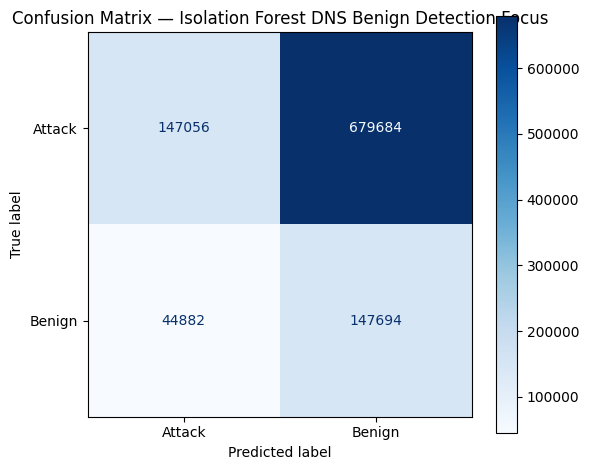

In [ ]:
cm = confusion_matrix(y_binary_benign_focus, y_pred_benign_focus)
# TN, FP, FN, TP are now relative to 'Benign' being the positive class
TN, FP, FN, TP = cm.ravel()

print("\n=== False Positive & False Negative Analysis (Benign as Positive Class) ===")
print(f"  True Positives  (benign caught)        : {TP:,}")
print(f"  True Negatives  (attack correct)        : {TN:,}")
print(f"  False Positives (attack flagged wrong)  : {FP:,}  ← FP Rate: {FP/(FP+TN)*100:.2f}%")
print(f"  False Negatives (benign missed)        : {FN:,}  ← FN Rate: {FN/(FN+TP)*100:.2f}%")

plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Attack', 'Benign']) # 0=Attack, 1=Benign
disp.plot(cmap='Blues', values_format='d', ax=plt.gca())
plt.title("Confusion Matrix — Isolation Forest DNS Benign Detection Focus")
plt.tight_layout()
plt.savefig("iso_confusion_matrix_benign_focus.png", dpi=150)
plt.show()